In [3]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import netCDF4 as nc
from salishsea_tools import viz_tools
from salishsea_tools import visualisations as vis
from mpl_toolkits.axes_grid1 import make_axes_locatable
import cmocean.cm as cm
import arrow

In [5]:
meshmask = xr.open_dataset('/ocean/atall/MOAD/grid/mesh_mask_202310b.nc')
tmask = meshmask.tmask
mbathy = meshmask.mbathy
bathy = nc.Dataset('/ocean/atall/MOAD/grid/bathymetry_202310b.nc')

thalweg_SI = '/ocean/atall/MOAD/analysis-abdoul/notebooks/thalweg_work/thalweg_files/SaanichInlet_thalweg.txt' 
thalweg_PB = '/ocean/atall/MOAD/analysis-abdoul/notebooks/thalweg_work/thalweg_files/PatriciaBay_CrossSection.txt' 
thalweg_SoG = '/ocean/atall/MOAD/analysis-abdoul/notebooks/thalweg_work/thalweg_files/thalweg_working.txt' 
thalweg_ptsSI = np.loadtxt(thalweg_SI, delimiter=' ', dtype=int)
thalweg_ptsPB = np.loadtxt(thalweg_PB, delimiter=' ', dtype=int)
thalweg_ptsSoG = np.loadtxt(thalweg_SoG, delimiter=' ', dtype=int)
mesh = nc.Dataset('/ocean/atall/MOAD/grid/mesh_mask_202310b.nc')
depth = mesh.variables['gdept_0'][:]

In [6]:
def plot_box(ax, corn, colour):
    ax.plot([corn[2], corn[3], corn[3], corn[2], corn[2]], 
            [corn[0], corn[0], corn[1], corn[1], corn[0]], '-', color=colour)

Text(0, 0.5, 'Depth [m]')

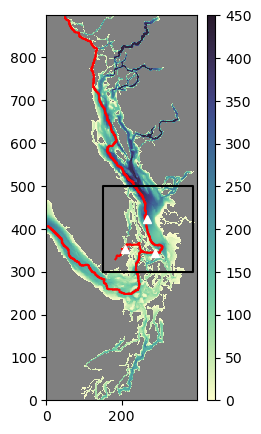

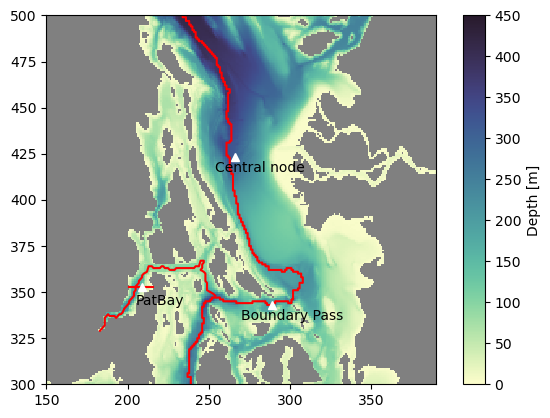

In [8]:
line, col = (1, 1)
mycmap = cm.deep
mycmap.set_bad('grey')
thalweg=thalweg_ptsSI
thalweg2=thalweg_ptsPB
thalweg3=thalweg_ptsSoG
zone_zoom = [300, 500, 150, 390]
fig, ax = plt.subplots(line, col, figsize=(6, 5))
#ax.set_xlim([150, 390])
#ax.set_ylim([300, 500])
vmin,vmax=(0,450)
im = ax.pcolormesh(bathy.variables['Bathymetry'][:], cmap=mycmap, vmin=vmin, vmax=vmax)
ax.plot(thalweg[:,1],thalweg[:,0],color='r')
ax.plot(thalweg2[:,1],thalweg2[:,0],color='r')
ax.plot(thalweg3[:,1],thalweg3[:,0],color='r')
ax.plot(209, 353,'w^') # Patricia bay
#ax.plot(205, 353,'w^')
ax.plot(266, 423,'w^') # Central node
ax.plot(289, 343,'w^') # Boundary Pass
plot_box(ax, zone_zoom, 'k')
viz_tools.set_aspect(ax);
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.002)
fig.colorbar(im, cax=cax, orientation='vertical')
#fig.savefig('../../figures/figsAnalysiSOG/Zone.png', dpi=300)

fig, ax = plt.subplots(line, col, figsize=(6, 5))
ax.set_xlim([150, 390])
ax.set_ylim([300, 500])
vmin,vmax=(0,450)
im = ax.pcolormesh(bathy.variables['Bathymetry'][:], cmap=mycmap, vmin=vmin, vmax=vmax)
ax.plot(thalweg[:,1],thalweg[:,0],color='r')
ax.plot(thalweg2[:,1],thalweg2[:,0],color='r')
ax.plot(thalweg3[:,1],thalweg3[:,0],color='r')
ax.plot(209, 353,'w^') # Patricia bay
ax.text(205, 343,'PatBay',fontsize=10)
#ax.plot(205, 353,'w^')
#ax.text(198, 354, 'SI',fontsize=10)
ax.plot(266, 423,'w^') # Central node
ax.text(254, 415,'Central node',fontsize=10)
ax.plot(289, 343,'w^') # Boundary Pass
ax.text(270, 335, 'Boundary Pass',fontsize=10)
viz_tools.set_aspect(ax);
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.002)
cbar=fig.colorbar(im, cax=cax, orientation='vertical')
cbar.ax.set_ylabel('Depth [m]')
#fig.savefig('../../figures/figsAnalysiSOG/Zone_zoom.png', dpi=300)


Text(0.5, 0.09, 'Distance along thalweg [km]')

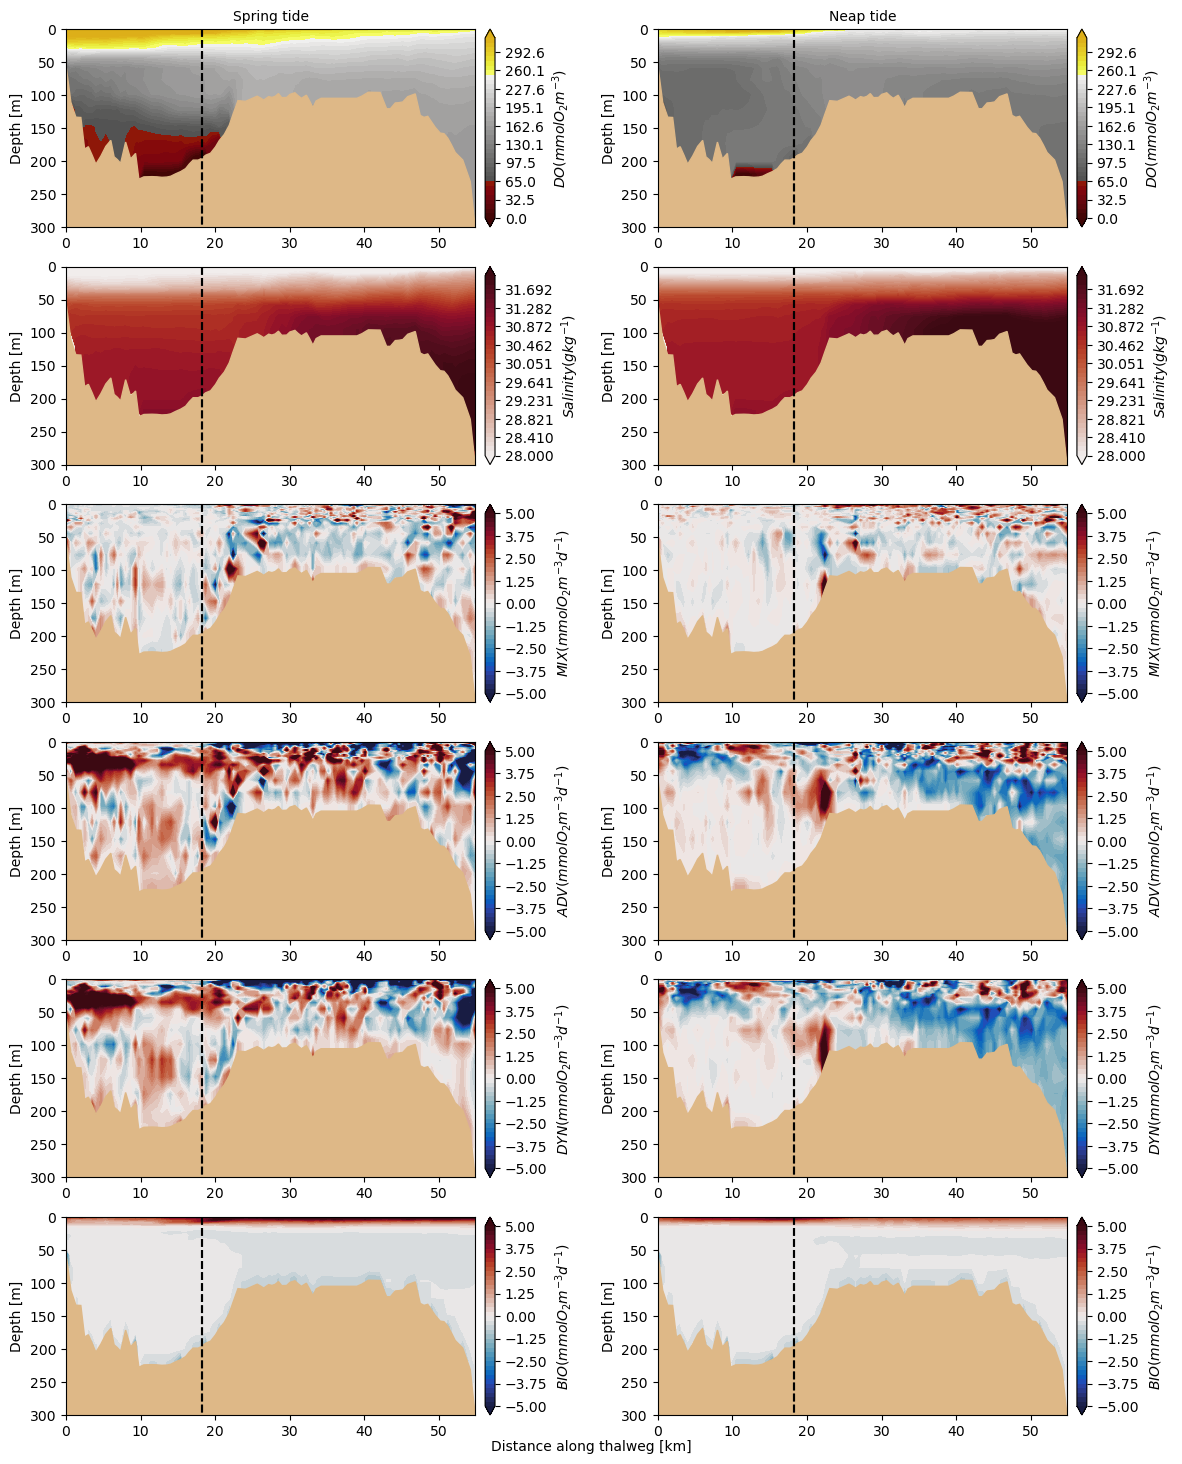

In [11]:
k, conv, line, col = (0, 86400, 6, 2)
fig, ax = plt.subplots(line, col, figsize=(14, 18))
thalweg = list([thalweg_ptsSI[::-1],thalweg_ptsPB])
depmin = list([300,200])
dir = '/ocean/atall/MOAD/Model/202410b/oxygen/'
period = list(['Spring tide','Neap tide'])

for j in range(col): #change period
    if j==0: # before the first deep water renew
        syear, smonth, sday = (2016, 6, 1)
        eyear, emonth, eday = (2016, 6, 3)
    else: # core of deep water renew
        syear, smonth, sday = (2016, 8, 10)
        eyear, emonth, eday = (2016, 8, 12)
    
    startdate = arrow.get(syear, smonth, sday)
    enddate = arrow.get(eyear, emonth, eday)
    first = True
    for iii, day in enumerate(arrow.Arrow.range('day', startdate, enddate)):
        year = day.year
        yr2 = day.strftime("%y")
        month = day.month
        Month = day.strftime("%b").lower()
        day = day.day
        # set up filename to follow NEMO conventions
        ds_chem = xr.open_dataset(f'{dir}{day:02}{Month}{yr2}/SalishSea_1d_{year}{month:02}{day:02}_{year}{month:02}{day:02}_chem_T.nc') 
        ds_biol = xr.open_dataset(f'{dir}{day:02}{Month}{yr2}/SalishSea_1d_{year}{month:02}{day:02}_{year}{month:02}{day:02}_biol_T.nc') 
        ds_diag = xr.open_dataset(f'{dir}{day:02}{Month}{yr2}/SalishSea_1d_{year}{month:02}{day:02}_{year}{month:02}{day:02}_diag_T.nc') 
        ds_grdT = xr.open_dataset(f'{dir}{day:02}{Month}{yr2}/SalishSea_1d_{year}{month:02}{day:02}_{year}{month:02}{day:02}_grid_T.nc') 
        
        dep_thal, distance, oxy_thal = vis.load_thalweg(depth[0, ...], np.array(ds_chem.dissolved_oxygen).mean(axis=0), bathy['nav_lon'][:], bathy['nav_lat'][:],thalweg[k])
        dep_thal, distance, zdf_thal = vis.load_thalweg(depth[0, ...], np.array(ds_diag.ZDF_O2).mean(axis=0), bathy['nav_lon'][:], bathy['nav_lat'][:],thalweg[k])
        dep_thal, distance, ldf_thal = vis.load_thalweg(depth[0, ...], np.array(ds_diag.LDF_O2).mean(axis=0), bathy['nav_lon'][:], bathy['nav_lat'][:],thalweg[k])
        dep_thal, distance, sms_thal = vis.load_thalweg(depth[0, ...], np.array(ds_diag.BIO_O2).mean(axis=0), bathy['nav_lon'][:], bathy['nav_lat'][:],thalweg[k])
        dep_thal, distance, rate_thal = vis.load_thalweg(depth[0, ...], np.array(ds_diag.PHS_O2).mean(axis=0), bathy['nav_lon'][:], bathy['nav_lat'][:],thalweg[k])
        dep_thal, distance, sal_thal = vis.load_thalweg(depth[0, ...], np.array(ds_grdT.vosaline).mean(axis=0), bathy['nav_lon'][:], bathy['nav_lat'][:],thalweg[k])
        if first:
            first = False
            oxyTS = oxy_thal
            salTS = sal_thal
            zdfTS = zdf_thal*conv 
            ldfTS = ldf_thal*conv
            smsTS = sms_thal*conv
            rateTS = rate_thal*conv
        else:
            oxyTS = np.vstack((oxyTS, oxy_thal))  
            salTS = np.vstack((salTS, sal_thal))  
            rateTS = np.vstack((rateTS, rate_thal)) 
            zdfTS = np.vstack((zdfTS, zdf_thal))
            ldfTS = np.vstack((ldfTS, ldf_thal))
            smsTS = np.vstack((smsTS, sms_thal)) 

    oxy = oxyTS.reshape(len(oxyTS)//len(ds_chem.dissolved_oxygen['deptht']),len(ds_chem.dissolved_oxygen['deptht']),len(thalweg[k])) 
    sal = salTS.reshape(len(salTS)//len(ds_chem.dissolved_oxygen['deptht']),len(ds_chem.dissolved_oxygen['deptht']),len(thalweg[k])) 
    rate = rateTS.reshape(len(rateTS)//len(ds_chem.dissolved_oxygen['deptht']),len(ds_chem.dissolved_oxygen['deptht']),len(thalweg[k]))    
    zdf = zdfTS.reshape(len(zdfTS)//len(ds_chem.dissolved_oxygen['deptht']),len(ds_chem.dissolved_oxygen['deptht']),len(thalweg[k])) 
    ldf = ldfTS.reshape(len(ldfTS)//len(ds_chem.dissolved_oxygen['deptht']),len(ds_chem.dissolved_oxygen['deptht']),len(thalweg[k])) 
    sms = smsTS.reshape(len(smsTS)//len(ds_chem.dissolved_oxygen['deptht']),len(ds_chem.dissolved_oxygen['deptht']),len(thalweg[k]))   
    for i in range (line):
        if i==0:
            cmap=cm.oxy
            var = oxy
            space = np.linspace(0, 317, 40)
            title = '$DO (mmolO_2m^{-3})$'
        elif i==1:
            cmap = cm.amp
            var = sal
            space = np.linspace(28, 32, 40)
            title = '$Salinity (g kg^{-1})$'
        elif i==2:
            cmap = cm.balance
            var = zdf+ldf
            space = np.linspace(-5, 5, 41)
            title = '$MIX (mmolO_2m^{-3}d^{-1})$'
        elif i==3:
            var = rate-zdf-ldf
            title = '$ADV (mmolO_2m^{-3}d^{-1})$'
        elif i==4:
            var = rate
            space = np.linspace(-5, 5, 41)
            title = '$DYN (mmolO_2m^{-3}d^{-1})$'
        elif i==5:
            var = sms
            space = np.linspace(-5, 5, 41)
            title = '$BIO (mmolO_2m^{-3}d^{-1})$'

        var_plot = vis._fill_in_bathy(var.mean(axis=0), mesh, thalweg[k])
        colours_var = ax[i,j].contourf(distance, dep_thal, var_plot, space, cmap=cmap, extend='both')
        vis._add_bathy_patch(distance, bathy['Bathymetry'][:], thalweg[k], ax[i,j], color='burlywood')
        ax[i,j].invert_yaxis()
        ax[i,j].set_ylabel('Depth [m]',fontsize=10)
        ax[i,j].set_ylim([depmin[k], 0])
        ax[0,j].set_title(f'{period[j]}',fontsize=10)
        cbar = plt.colorbar(colours_var, ax=ax[i,j], pad=0.02)
        cbar.ax.set_ylabel(f'{title}',fontsize=10)
        ax[i,j].plot([18.217, 18.217], [0, 300], 'k--')
        ax[i,j].plot([18.217, 18.217], [0, 300], 'k--')
    #ax[0,j].text(17, -5, 'SI')
fig.text(0.5, 0.09, 'Distance along thalweg [km]', ha='center')
#fig.text(0.09, 0.5, 'Depth [m]', va='center', rotation='vertical')
#fig.savefig('../../figures/figsAnalysiSOG/SaanichThalweg_202410b_O2-Salt-MIX-ADV-BIO_SpringNeapTide.png', dpi=300)


FileNotFoundError: [Errno 2] No such file or directory: '../../figures/figsAnalysiSOG/SaanichZonalSec_202410b_O2-Salt-MIX-ADV-BIO_SpringNeapTide.png'

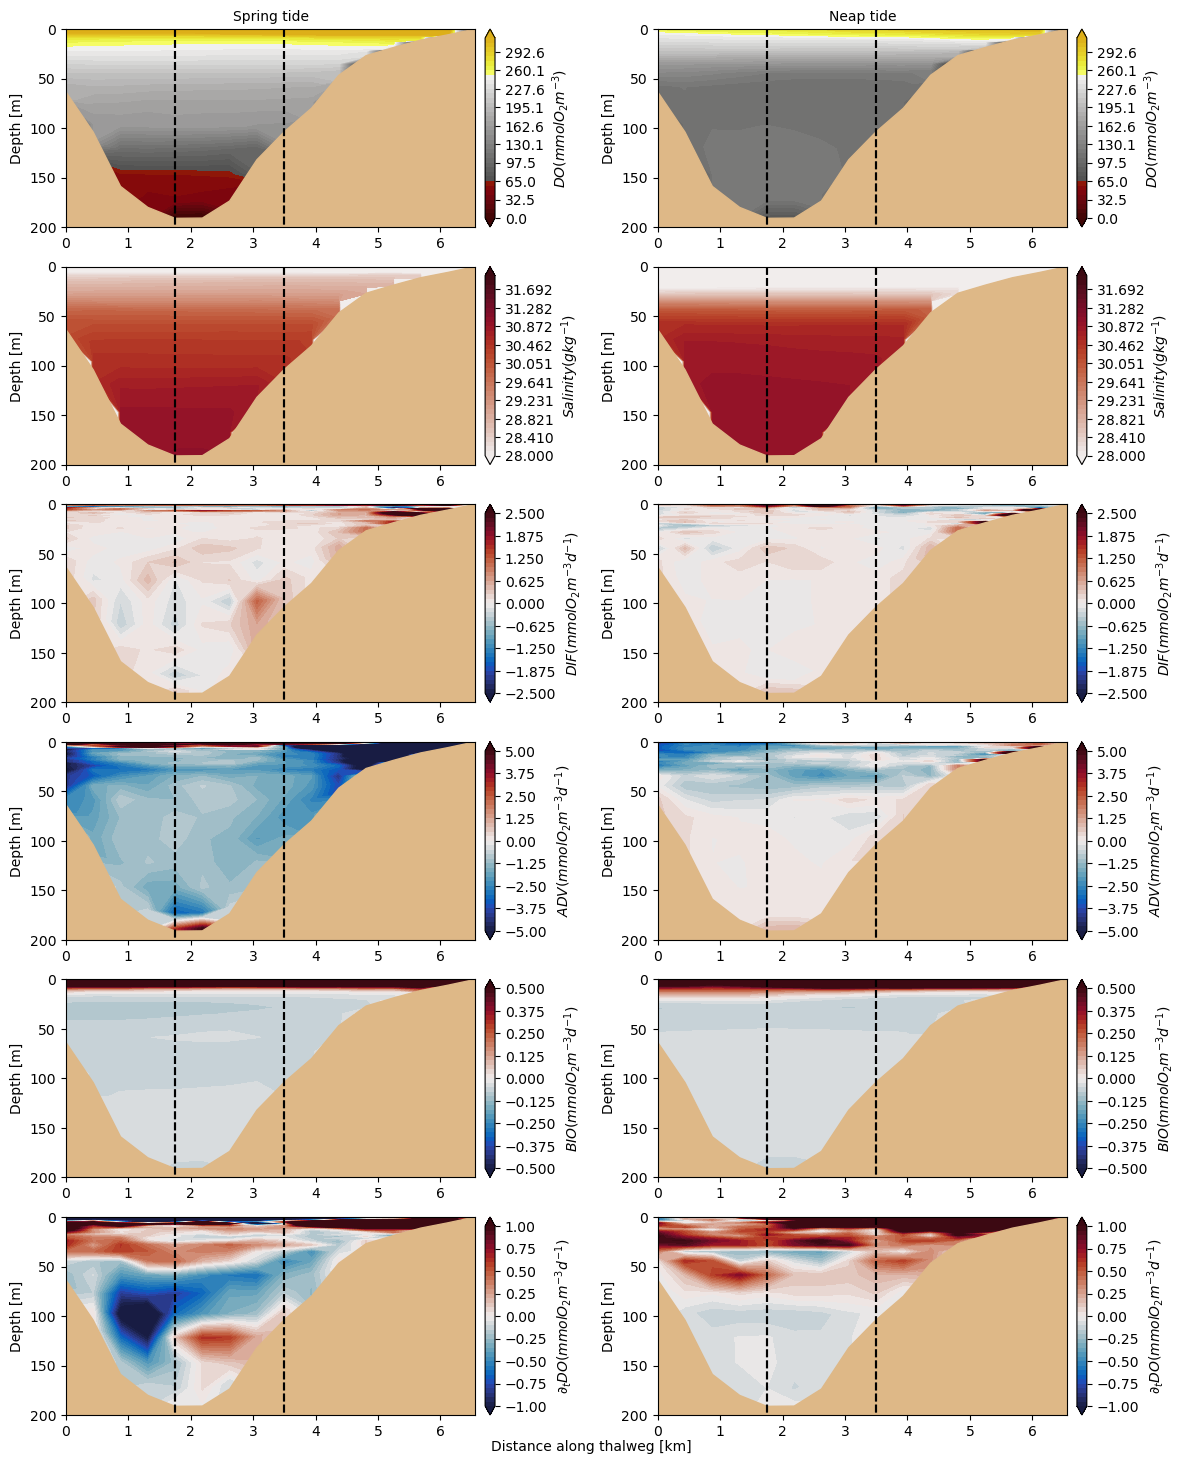

In [ ]:
k, conv, line, col = (1, 86400, 6, 2)
fig, ax = plt.subplots(line, col, figsize=(14, 18))
thalweg = list([thalweg_ptsSI[::-1],thalweg_ptsPB])
depmin = list([300,200])
dir = '/ocean/atall/MOAD/Model/202410b/oxygen/'
period = list(['Spring tide','Neap tide'])

for j in range(col): #change period
    if j==0: # before the first deep water renew
        syear, smonth, sday = (2012, 6, 5)
        eyear, emonth, eday = (2012, 6, 15)
    else: # core of deep water renew
        syear, smonth, sday = (2012, 9, 5)
        eyear, emonth, eday = (2012, 9, 15)
    
    startdate = arrow.get(syear, smonth, sday)
    enddate = arrow.get(eyear, emonth, eday)
    first = True
    for iii, day in enumerate(arrow.Arrow.range('day', startdate, enddate)):
        year = day.year
        yr2 = day.strftime("%y")
        month = day.month
        Month = day.strftime("%b").lower()
        day = day.day
        # set up filename to follow NEMO conventions
        ds_chem = xr.open_dataset(f'{dir}{day:02}{Month}{yr2}/SalishSea_1d_{year}{month:02}{day:02}_{year}{month:02}{day:02}_chem_T.nc') 
        ds_biol = xr.open_dataset(f'{dir}{day:02}{Month}{yr2}/SalishSea_1d_{year}{month:02}{day:02}_{year}{month:02}{day:02}_biol_T.nc') 
        ds_diag = xr.open_dataset(f'{dir}{day:02}{Month}{yr2}/SalishSea_1d_{year}{month:02}{day:02}_{year}{month:02}{day:02}_diag_T.nc') 
        ds_grdT = xr.open_dataset(f'{dir}{day:02}{Month}{yr2}/SalishSea_1d_{year}{month:02}{day:02}_{year}{month:02}{day:02}_grid_T.nc') 
        #sms0 = ds_diag.SMS_O2
        #sms0[:,mbathy[0,:,:]-1,:,:]=ds_diag.RATE_O2[:,mbathy[0,:,:]-1,:,:].where(tmask[0, mbathy[0,:,:]-1,:,:] == 1)- (
        #                            ds_diag.TAD_O2[:,mbathy[0,:,:]-1,:,:].where(tmask[0, mbathy[0,:,:]-1,:,:] == 1) +
        #                            ds_diag.ZDF_O2[:,mbathy[0,:,:]-1,:,:].where(tmask[0, mbathy[0,:,:]-1,:,:] == 1) +
        #                            ds_diag.LDF_O2[:,mbathy[0,:,:]-1,:,:].where(tmask[0, mbathy[0,:,:]-1,:,:] == 1)
        #)
        dep_thal, distance, oxy_thal = vis.load_thalweg(depth[0, ...], np.array(ds_chem.dissolved_oxygen).mean(axis=0), bathy['nav_lon'][:], bathy['nav_lat'][:],thalweg[k])
        dep_thal, distance, zdf_thal = vis.load_thalweg(depth[0, ...], np.array(ds_diag.ZDF_O2).mean(axis=0), bathy['nav_lon'][:], bathy['nav_lat'][:],thalweg[k])
        dep_thal, distance, ldf_thal = vis.load_thalweg(depth[0, ...], np.array(ds_diag.LDF_O2).mean(axis=0), bathy['nav_lon'][:], bathy['nav_lat'][:],thalweg[k])
        dep_thal, distance, sms_thal = vis.load_thalweg(depth[0, ...], np.array(ds_diag.SMS_O2).mean(axis=0), bathy['nav_lon'][:], bathy['nav_lat'][:],thalweg[k])
        dep_thal, distance, rate_thal = vis.load_thalweg(depth[0, ...], np.array(ds_diag.PHS_O2).mean(axis=0), bathy['nav_lon'][:], bathy['nav_lat'][:],thalweg[k])
        dep_thal, distance, sal_thal = vis.load_thalweg(depth[0, ...], np.array(ds_grdT.vosaline).mean(axis=0), bathy['nav_lon'][:], bathy['nav_lat'][:],thalweg[k])
        if first:
            first = False
            oxyTS = oxy_thal
            salTS = sal_thal
            zdfTS = zdf_thal*conv 
            ldfTS = ldf_thal*conv
            smsTS = sms_thal*conv
            rateTS = rate_thal*conv
        else:
            oxyTS = np.vstack((oxyTS, oxy_thal))  
            salTS = np.vstack((salTS, sal_thal))  
            rateTS = np.vstack((rateTS, rate_thal)) 
            zdfTS = np.vstack((zdfTS, zdf_thal))
            ldfTS = np.vstack((ldfTS, ldf_thal))
            smsTS = np.vstack((smsTS, sms_thal)) 

    oxy = oxyTS.reshape(len(oxyTS)//len(ds_chem.dissolved_oxygen['deptht']),len(ds_chem.dissolved_oxygen['deptht']),len(thalweg[k])) 
    sal = salTS.reshape(len(salTS)//len(ds_chem.dissolved_oxygen['deptht']),len(ds_chem.dissolved_oxygen['deptht']),len(thalweg[k])) 
    rate = rateTS.reshape(len(rateTS)//len(ds_chem.dissolved_oxygen['deptht']),len(ds_chem.dissolved_oxygen['deptht']),len(thalweg[k]))    
    zdf = zdfTS.reshape(len(zdfTS)//len(ds_chem.dissolved_oxygen['deptht']),len(ds_chem.dissolved_oxygen['deptht']),len(thalweg[k])) 
    ldf = ldfTS.reshape(len(ldfTS)//len(ds_chem.dissolved_oxygen['deptht']),len(ds_chem.dissolved_oxygen['deptht']),len(thalweg[k])) 
    sms = smsTS.reshape(len(smsTS)//len(ds_chem.dissolved_oxygen['deptht']),len(ds_chem.dissolved_oxygen['deptht']),len(thalweg[k]))   
    #sms[:,mbathy[0, thalweg[k]]-1,:]=rate[:,-1,:]-(adv[:,-1,:]+zdf[:,-1,:]+ldf[:,-1,:]) # lack bottom sinking in SMS, computed using rate term
    for i in range (line):
        if i==0:
            cmap=cm.oxy
            var = oxy
            space = np.linspace(0, 317, 40)
            title = '$DO (mmolO_2m^{-3})$'
        elif i==1:
            cmap = cm.amp
            var = sal
            space = np.linspace(28, 32, 40)
            title = '$Salinity (g kg^{-1})$'
        elif i==2:
            cmap = cm.balance
            var = zdf+ldf
            space = np.linspace(-2.5, 2.5, 41)
            title = '$DIF (mmolO_2m^{-3}d^{-1})$'
        elif i==3:
            cmap = cm.balance
            var = rate-zdf-ldf
            space = np.linspace(-5, 5, 41)
            title = '$ADV (mmolO_2m^{-3}d^{-1})$'
        elif i==4:
            cmap = cm.balance
            var = sms
            space = np.linspace(-0.5, 0.5, 41)
            title = '$BIO (mmolO_2m^{-3}d^{-1})$'
        elif i==5:
            cmap = cm.balance
            var = rate
            space = np.linspace(-1, 1, 41)
            title = '$\partial _t{DO} (mmolO_2m^{-3}d^{-1})$'

        var_plot = vis._fill_in_bathy(var.mean(axis=0), mesh, thalweg[k])
        colours_var = ax[i,j].contourf(distance, dep_thal, var_plot, space, cmap=cmap, extend='both')
        vis._add_bathy_patch(distance, bathy['Bathymetry'][:], thalweg[k], ax[i,j], color='burlywood')
        ax[i,j].invert_yaxis()
        ax[i,j].set_ylabel('Depth [m]',fontsize=10)
        ax[i,j].set_ylim([depmin[k], 0])
        ax[0,j].set_title(f'{period[j]}',fontsize=10)
        cbar = plt.colorbar(colours_var, ax=ax[i,j], pad=0.02)
        cbar.ax.set_ylabel(f'{title}',fontsize=10)
        ax[i,j].plot([1.75, 1.75], [0, 300], 'k--')
        ax[i,j].plot([1.75, 1.75], [0, 300], 'k--')
        ax[i,j].plot([3.5, 3.5], [0, 300], 'k--')
        ax[i,j].plot([3.5, 3.5], [0, 300], 'k--')
    #ax[0,j].text(1.4, -5, 'SI')
    #ax[0,j].text(2, -5, 'PatBay')
fig.text(0.5, 0.09, 'Distance along thalweg [km]', ha='center')
#fig.text(0.09, 0.5, 'Depth [m]', va='center', rotation='vertical')
#fig.savefig('../../figures/figsAnalysiSOG/SaanichZonalSec_202410b_O2-Salt-MIX-ADV-BIO_SpringNeapTide.png', dpi=300)
